# Reversal detection

Here, I detect emotional reversals in the secondary arc of each script. It runs entirely locally on the pre-computed arcs in `thesis-outputs/arcs/arcs_all.json`. No model inference needed. I define "reversal" as a local peak or trough in the Savitzky-Golay smoothed secondary arc. For each script I record: the total number of reversals, the normalized story position of each reversal (0–1), whether it is a peak (positive > negative turn) or a trough (negative > positive turn), and the sentiment value at that point. This lets me compare not just how many reversals a film contains, but where in the story they tend to cluster.

## 1. Load arcs

In [1]:
%pip install -q scipy numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import numpy as np
from pathlib import Path
from scipy.signal import find_peaks

LOCAL_ROOT = Path('/Users/derinsavasan/Desktop/parsons-spring/thesis')
ARCS_ALL   = LOCAL_ROOT / 'docs/thesis-outputs/arcs_all.json'

all_arcs = json.loads(ARCS_ALL.read_text())
print(f'Loaded {len(all_arcs)} arcs')

Loaded 1627 arcs


## 2. Detect reversals

I use `scipy.signal.find_peaks` on the smoothed secondary arc to find peaks, and on its inverse to find troughs. The `prominence` parameter controls how significant a swing needs to be to count as a reversal. I ignore small ripples and only record meaningful directional changes. I set the prominance to 0.5 (on the signed sentiment scale of −1 to +1). This can be tuned, of course.

In [3]:
PROMINENCE = 0.5  # minimum prominence to count as a reversal

results = []

for arc in all_arcs:
    secondary = arc['secondary_arc']
    if not secondary:
        continue

    positions = np.array([w['position']       for w in secondary])
    values    = np.array([w['smoothed_score'] for w in secondary])

    # Peaks — sentiment goes up then down
    peak_idxs,   _ = find_peaks( values, prominence=PROMINENCE)
    # Troughs — sentiment goes down then up
    trough_idxs, _ = find_peaks(-values, prominence=PROMINENCE)

    reversals = [
        {'position': float(positions[i]), 'value': float(values[i]), 'type': 'peak'}
        for i in peak_idxs
    ] + [
        {'position': float(positions[i]), 'value': float(values[i]), 'type': 'trough'}
        for i in trough_idxs
    ]
    reversals.sort(key=lambda r: r['position'])

    results.append({
        'slug':        arc['slug'],
        'title':       arc['title'],
        'imdb_id':     arc['imdb_id'],
        'year':        arc['year'],
        'n_reversals': len(reversals),
        'reversals':   reversals,
    })

print(f'Processed {len(results)} scripts')
print(f'Avg reversals per film : {np.mean([r["n_reversals"] for r in results]):.1f}')
print(f'Max reversals          : {max(r["n_reversals"] for r in results)}')
print(f'Min reversals          : {min(r["n_reversals"] for r in results)}')

Processed 1627 scripts
Avg reversals per film : 10.8
Max reversals          : 31
Min reversals          : 0


## 3. Save

In [4]:
out = LOCAL_ROOT / 'docs/thesis-outputs/reversals.json'
out.write_text(json.dumps(results, indent=2))
print(f'Saved -> {out}')

Saved -> /Users/derinsavasan/Desktop/parsons-spring/thesis/docs/thesis-outputs/reversals.json


## 4. Spot-check one script

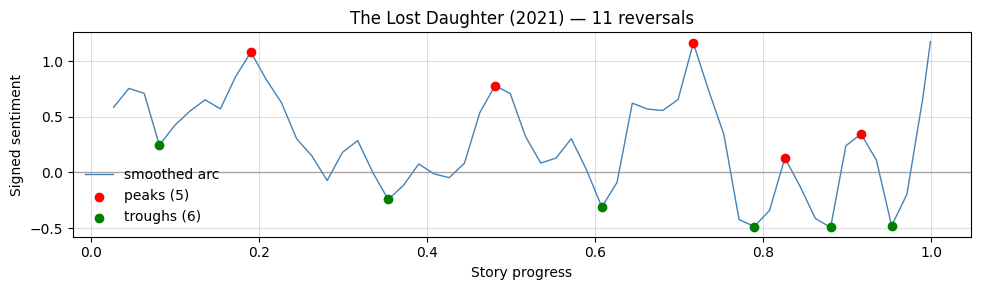

In [16]:
import random, matplotlib.pyplot as plt

# Pick a random script
arc    = random.choice(all_arcs)
result = next(r for r in results if r['slug'] == arc['slug'])

positions = [w['position']       for w in arc['secondary_arc']]
values    = [w['smoothed_score'] for w in arc['secondary_arc']]

peaks   = [r for r in result['reversals'] if r['type'] == 'peak']
troughs = [r for r in result['reversals'] if r['type'] == 'trough']

plt.figure(figsize=(10, 3))
plt.plot(positions, values, linewidth=1, color='steelblue', label='smoothed arc')
plt.scatter([r['position'] for r in peaks],   [r['value'] for r in peaks],
            color='red',   zorder=5, label=f'peaks ({len(peaks)})')
plt.scatter([r['position'] for r in troughs], [r['value'] for r in troughs],
            color='green', zorder=5, label=f'troughs ({len(troughs)})')
plt.axhline(0, color='gray', lw=1, alpha=0.6)
plt.title(f"{result['title']} ({result['year']}) — {result['n_reversals']} reversals")
plt.xlabel('Story progress')
plt.ylabel('Signed sentiment')
plt.legend(frameon=False)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()